<h1 style="text-align:center;">Projeto Final: Alzheimer's Disease Dataset </h1>



In [1]:
#pip install pandas seaborn numpy scikit-learn matplotlib plotly.express

<h2 style="text-align:center;">Pré-Processamento dos Dados</h2>


In [2]:
import pandas as pd

df = pd.read_csv('alzheimers_disease_data.csv')

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df.columns = df.columns.map({'PatientID':'ID_Paciente',
                             'Age':'Idade',
                             'Gender':'Genero', #0: masculino; 1: feminino
                             'Ethnicity':'Etnia', #0: Caucasiano; 1: Afro-americano; 2: Asiático; 3: Outro
                             'EducationLevel':'Nivel_Educacao', #0: Nenhum; 1: Ensino Médio; 2: Bacharelado; 3: Ensino Superior
                             'BMI':'IMC',
                             'Smoking':'Fumante', #Categórico
                             'AlcoholConsumption':'Consumo_Alcool',
                             'PhysicalActivity':'Atividade_Fisica',
                             'DietQuality':'Qualidade_Dieta',
                             'SleepQuality':'Qualidade_Sono',
                             'FamilyHistoryAlzheimers':'Historico_Familiar_Alzheimer', #Categórico
                             'CardiovascularDisease':'Doenca_Cardiovascular', #Categórico
                             'Diabetes':'Diabetes', #Categórico
                             'Depression':'Depressao', #Categórico 
                             'HeadInjury':'Traumatismo_Craniano', #Categórico
                             'Hypertension':'Hipertensao', #Categórico
                             'SystolicBP':'Pressao_Sistolica',
                             'DiastolicBP':'Pressao_Diastolica',
                             'CholesterolTotal':'Colesterol_Total',
                             'CholesterolLDL':'Colesterol_LDL',
                             'CholesterolHDL':'Colesterol_HDL',
                             'CholesterolTriglycerides':'Triglicerideos',
                             'MMSE':'MMSE', #Mini Exame do Estado Mental
                             'FunctionalAssessment':'Avaliacao_Funcional',
                             'MemoryComplaints':'Queixas_Memoria', #Categórico
                             'BehavioralProblems':'Problemas_Comportamentais', #Categórico
                             'ADL':'Atividades_Vida_Diaria',
                             'Confusion':'Confusao', #Categórico
                             'Disorientation':'Desorientacao', #Categórico 
                             'PersonalityChanges':'Mudancas_Personalidade', #Categórico
                             'DifficultyCompletingTasks':'Dificuldade_Tarefas', #Categórico
                             'Forgetfulness':'Esquecimento', #Categórico
                             'Diagnosis':'Diagnostico', # classificação
                             'DoctorInCharge':'Medico_Responsavel'
                             })
df.head()

,ID_Paciente,Idade,Genero,Etnia,Nivel_Educacao,IMC,Fumante,Consumo_Alcool,Atividade_Fisica,Qualidade_Dieta,...,Queixas_Memoria,Problemas_Comportamentais,Atividades_Vida_Diaria,Confusao,Desorientacao,Mudancas_Personalidade,Dificuldade_Tarefas,Esquecimento,Diagnostico,Medico_Responsavel
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


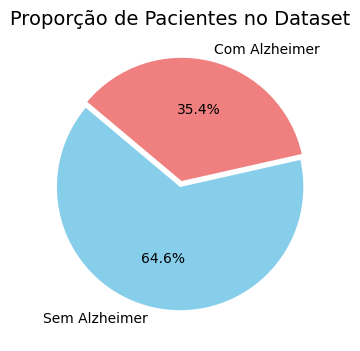

In [3]:
import matplotlib.pyplot as plt

contagem = df['Diagnostico'].value_counts()
labels = ['Sem Alzheimer', 'Com Alzheimer']
cores = ['skyblue', 'lightcoral']

plt.figure(figsize=(4, 4))
plt.pie(contagem, labels=labels, autopct='%1.1f%%', startangle=140, colors=cores, explode=(0, 0.05))
plt.title('Proporção de Pacientes no Dataset', fontsize=14)
plt.show()

<h2 style="text-align:center;">Normalização dos Dados</h2> 

<h3>Removendo Colunas que não são interessantes para a análise.</h3>

In [4]:
import numpy as np

disposable_col = ["ID_Paciente", "Medico_Responsavel"]

df_analise = df.drop(columns=disposable_col)
df_analise.head()

,Idade,Genero,Etnia,Nivel_Educacao,IMC,Fumante,Consumo_Alcool,Atividade_Fisica,Qualidade_Dieta,Qualidade_Sono,...,Avaliacao_Funcional,Queixas_Memoria,Problemas_Comportamentais,Atividades_Vida_Diaria,Confusao,Desorientacao,Mudancas_Personalidade,Dificuldade_Tarefas,Esquecimento,Diagnostico
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0


<h3>Normalização dos dados</h3>

In [5]:
colCategoricas = ['Genero', 'Etnia', 'Nivel_Educacao', 'Fumante', 
                  'Historico_Familiar_Alzheimer', 'Doenca_Cardiovascular', 
                  'Diabetes', 'Depressao', 'Traumatismo_Craniano', 'Hipertensao', 
                  'Queixas_Memoria', 'Problemas_Comportamentais', 'Confusao', 'Desorientacao', 
                  'Mudancas_Personalidade', 'Dificuldade_Tarefas', 'Esquecimento']

for col in df_analise.drop(columns=colCategoricas):
    df_analise[col] = (df_analise[col] - df_analise[col].min()) / (df_analise[col].max() - df_analise[col].min())

df_analise.head()

,Idade,Genero,Etnia,Nivel_Educacao,IMC,Fumante,Consumo_Alcool,Atividade_Fisica,Qualidade_Dieta,Qualidade_Sono,...,Avaliacao_Funcional,Queixas_Memoria,Problemas_Comportamentais,Atividades_Vida_Diaria,Confusao,Desorientacao,Mudancas_Personalidade,Dificuldade_Tarefas,Esquecimento,Diagnostico
0,0.433333,0,0,2,0.316960,0,0.665183,0.633375,0.133931,0.837564,...,0.652102,0,0,0.172486,0,0,0,1,0,0.0
1,0.966667,0,0,0,0.473058,0,0.227170,0.762862,0.050995,0.525021,...,0.712108,0,0,0.259154,0,0,0,0,1,0.0
2,0.433333,0,3,1,0.111553,0,0.978276,0.785408,0.181896,0.945597,...,0.589697,0,0,0.711936,0,1,0,1,0,0.0
3,0.466667,1,0,1,0.752163,1,0.610751,0.843804,0.743443,0.731994,...,0.896823,0,1,0.648094,0,0,0,0,0,0.0
4,0.966667,0,0,0,0.228472,0,0.923204,0.631707,0.078698,0.265892,...,0.604699,0,0,0.001341,0,0,1,1,0,0.0


<h3>Matriz de Correlação</h3>

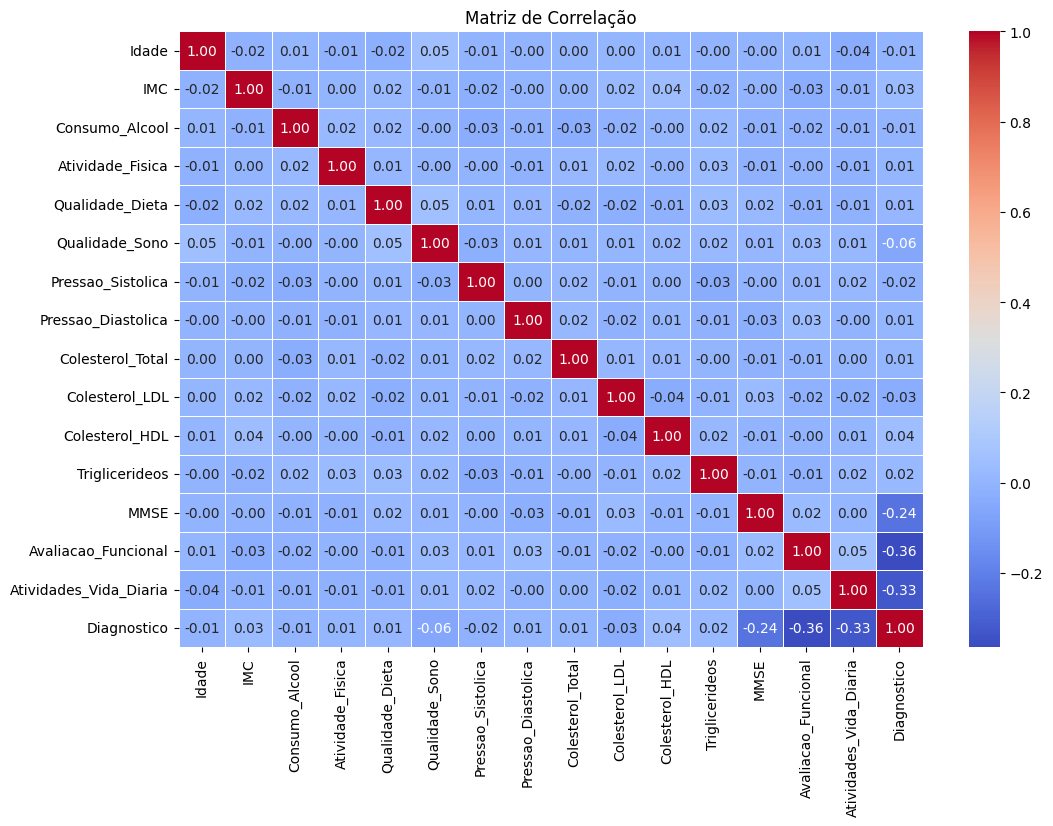

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df_corr = df_analise.drop(columns=colCategoricas)

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlação")
plt.show()

<h3>Cálculo do PCA com <b>Duas</b> Componentes</h3>

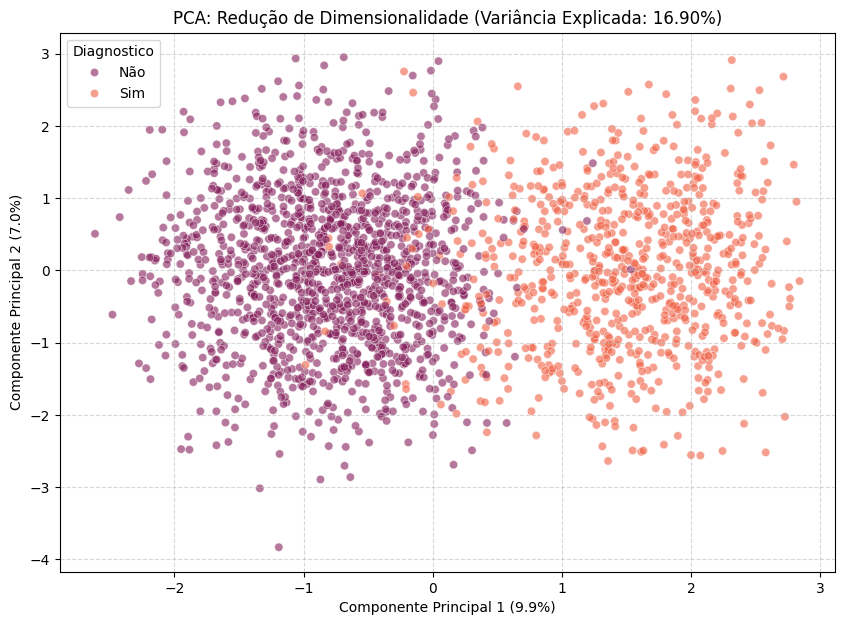

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df_analise.drop(columns=colCategoricas)
y = df_analise['Diagnostico']  

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data = X_pca, columns = ['PC1', 'PC2'])
df_pca['Diagnostico'] = y.map({0: 'Não', 1: 'Sim'}).values

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Diagnostico', data=df_pca, palette='rocket', alpha=0.6)
plt.title(f'PCA: Redução de Dimensionalidade (Variância Explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%)')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

<h3>Cálculo do PCA com <b>Três</b> Componentes</h3>

In [8]:
import plotly.express as px

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['Label'] = y.map({0: 'Não', 1: 'Sim'})

fig = px.scatter_3d(
    df_pca,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Label',
    title=f'PCA 3D (Variância Explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%)',
    labels={
        'PC1': f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
        'PC2': f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
        'PC3': f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)'
    }
)

fig.show()

<h2 style="text-align:center">Distribuição de Frequência</h2>

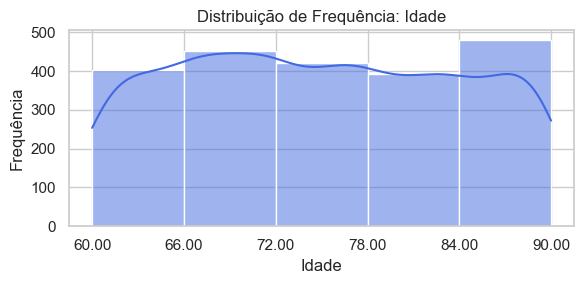

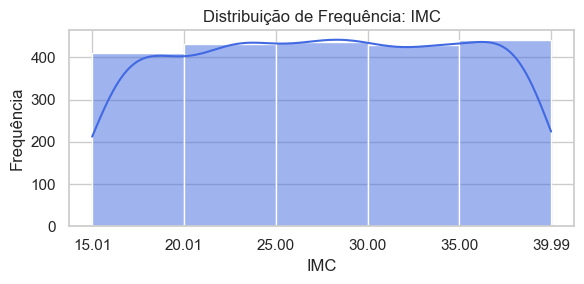

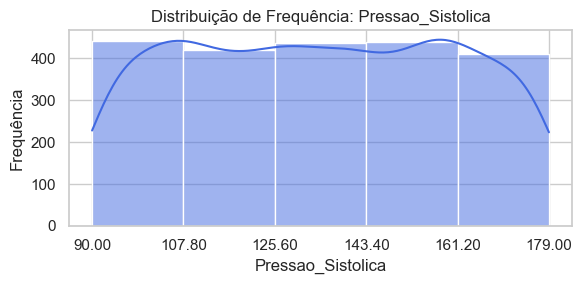

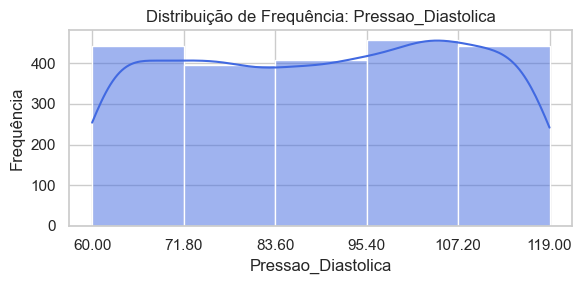

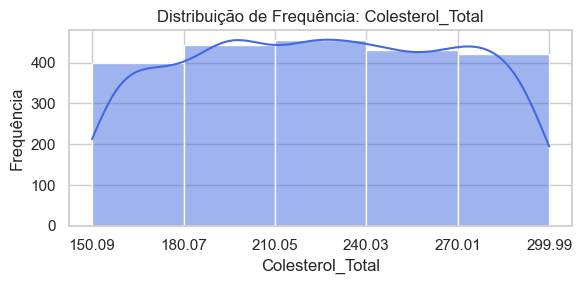

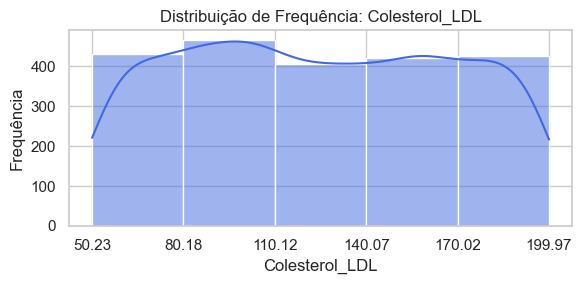

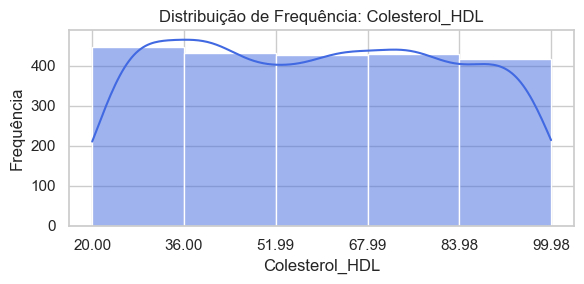

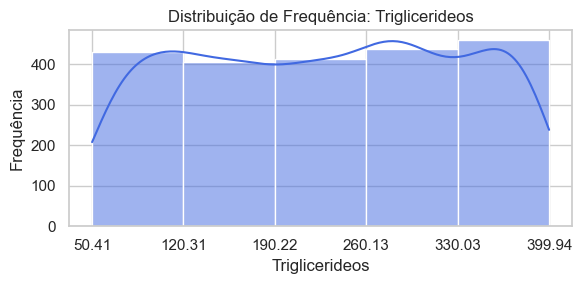

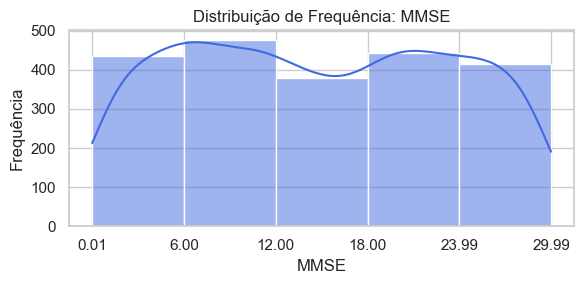

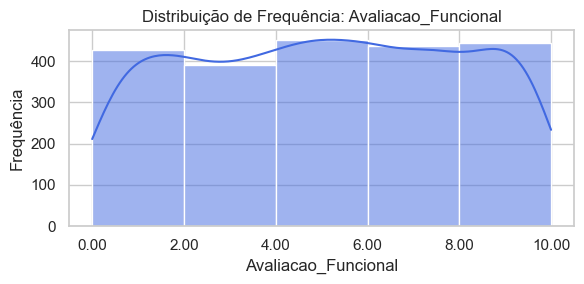

In [9]:
df_medidas = df.drop(columns=disposable_col)

colMedidas = ['Idade', 'IMC', 'Pressao_Sistolica', 'Pressao_Diastolica', 
              'Colesterol_Total', 'Colesterol_LDL', 'Colesterol_HDL', 
              'Triglicerideos', 'MMSE', 'Avaliacao_Funcional']

for col in colMedidas:
    v_min = df_medidas[col].min()
    v_max = df_medidas[col].max()
    
    ticks = np.linspace(v_min, v_max, 6)

    plt.figure(figsize=(6, 3))
    sns.set_theme(style="whitegrid")

    ax = sns.histplot(df_medidas[col], bins=5, kde=True, color='royalblue')
    
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{x:.2f}" for x in ticks])

    plt.title(f'Distribuição de Frequência: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
    
    plt.tight_layout()
    plt.show()

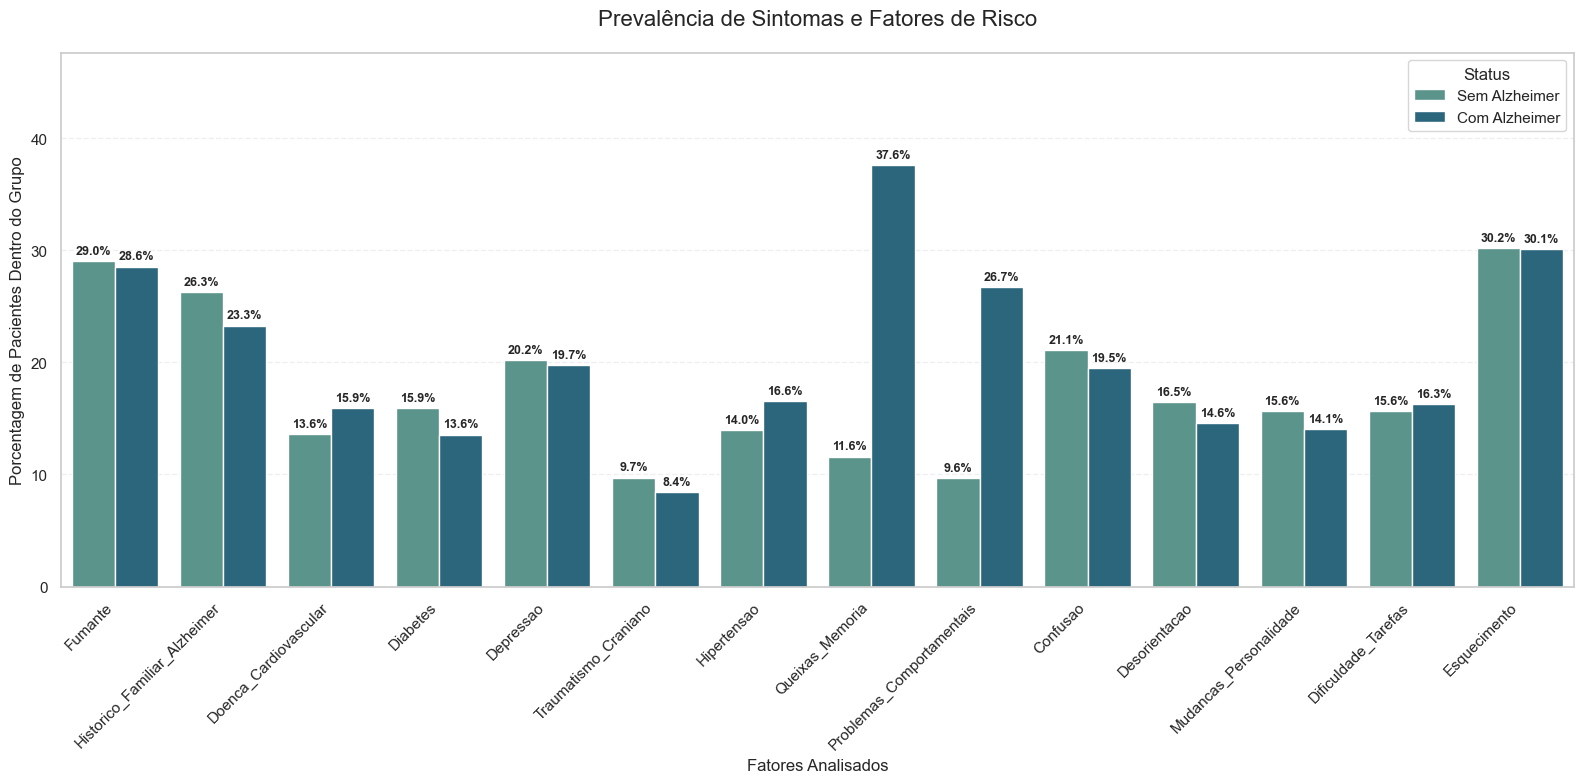

In [10]:
fatores_risco = [
    'Fumante', 'Historico_Familiar_Alzheimer', 'Doenca_Cardiovascular', 'Diabetes',
    'Depressao', 'Traumatismo_Craniano', 'Hipertensao', 'Queixas_Memoria',
    'Problemas_Comportamentais', 'Confusao', 'Desorientacao',
    'Mudancas_Personalidade', 'Dificuldade_Tarefas', 'Esquecimento'
]

dados_percentuais = []
for fator in fatores_risco:
    pcts = df.groupby('Diagnostico')[fator].mean() * 100
    dados_percentuais.append({'Variável': fator, 'Diagnostico': 'Sem Alzheimer', 'Porcentagem': pcts[0]})
    dados_percentuais.append({'Variável': fator, 'Diagnostico': 'Com Alzheimer', 'Porcentagem': pcts[1]})

df_plot = pd.DataFrame(dados_percentuais)
plt.figure(figsize=(16, 8))
ax = sns.barplot(data=df_plot, x='Variável', y='Porcentagem', hue='Diagnostico', palette='crest')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9, fontweight='bold')

plt.title('Prevalência de Sintomas e Fatores de Risco', fontsize=16, pad=20)
plt.ylabel('Porcentagem de Pacientes Dentro do Grupo', fontsize=12)
plt.xlabel('Fatores Analisados', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, df_plot['Porcentagem'].max() + 10)
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

<h2 style="text-align:center;">Medidas de Resumo</h2>
<h3>Medidas de Tendência Central</h3>

In [11]:
from IPython.display import display, Markdown

dadosTC = []

for col in colMedidas:
    Min = df_medidas[col].min()
    Max = df_medidas[col].max()
    Media = df_medidas[col].mean()
    Moda = df_medidas[col].mode()[0]
    PontoMedio = (Min + Max) / 2
    Mediana = df_medidas[col].median()

    dadosTC.append({
        'Variável': col,
        'Intervalo': f"{Min:.0f} - {Max:.0f}",
        'Média': Media,
        'Mediana': Mediana,
        'Ponto Médio': PontoMedio,
        'Moda': Moda
    })

tabela = pd.DataFrame(dadosTC)
tabela = tabela.set_index('Variável').round(2)

display(Markdown("### Tabela das Medidas de Tendencia Central dos Dados."))
tabela


### Tabela das Medidas de Tendencia Central dos Dados.

,Intervalo,Média,Mediana,Ponto Médio,Moda
Variável,,,,,
Idade,60 - 90,74.91,75.00,75.00,68.00
IMC,15 - 40,27.66,27.82,27.50,15.01
Pressao_Sistolica,90 - 179,134.26,134.00,134.50,155.00
Pressao_Diastolica,60 - 119,89.85,91.00,89.50,61.00
Colesterol_Total,150 - 300,225.20,225.09,225.04,150.09
Colesterol_LDL,50 - 200,124.34,123.34,125.10,50.23
Colesterol_HDL,20 - 100,59.46,59.77,59.99,20.00
Triglicerideos,50 - 400,228.28,230.30,225.17,50.41
MMSE,0 - 30,14.76,14.44,15.00,0.01


<h3>Medidas de Dispersão</h3>

In [12]:
dadosMD = []

for col in colMedidas:
    Amplitude = df_medidas[col].max() - df_medidas[col].min()
    Desvio = df_medidas[col].std()
    Variancia = Desvio**2
    Coeficiente = Desvio / df_medidas[col].mean()

    dadosMD.append({
        'Variável': col,
        'Amplitude': Amplitude,
        'Desvio Padrão': Desvio,
        'Variância': Variancia,
        'Coeficiente de Variação': f"{Coeficiente:.2%}"
    })

tabela = pd.DataFrame(dadosMD)
tabela = tabela.set_index('Variável').round(2)

display(Markdown("### Tabela das Medidas de Dispersão dos Dados."))
tabela

### Tabela das Medidas de Dispersão dos Dados.

,Amplitude,Desvio Padrão,Variância,Coeficiente de Variação
Variável,,,,
Idade,30.00,8.99,80.82,12.00%
IMC,24.98,7.22,52.09,26.10%
Pressao_Sistolica,89.00,25.95,673.37,19.33%
Pressao_Diastolica,59.00,17.59,309.50,19.58%
Colesterol_Total,149.90,42.54,1809.84,18.89%
Colesterol_LDL,149.73,43.37,1880.66,34.88%
Colesterol_HDL,79.98,23.14,535.42,38.91%
Triglicerideos,349.53,101.99,10401.29,44.68%
MMSE,29.99,8.61,74.19,58.37%


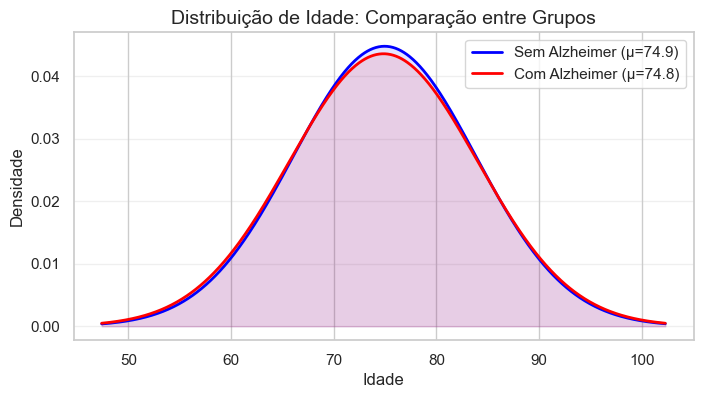

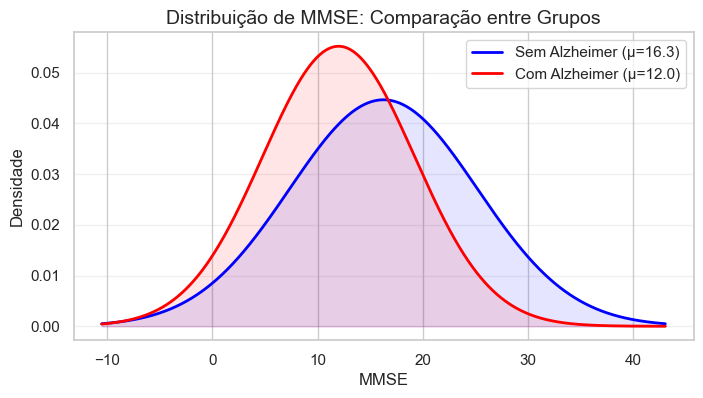

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

def compararDistribuicao(coluna, df):
    grupoN = df[df['Diagnostico'] == 0][coluna].dropna()
    grupoS = df[df['Diagnostico'] == 1][coluna].dropna()

    muN, stdN = grupoN.mean(), grupoN.std()
    muS, stdS = grupoS.mean(), grupoS.std()

    x = np.linspace(min(muN-3*stdN, muS-3*stdS), max(muN+3*stdN, muS+3*stdS), 1000)

    plt.figure(figsize=(8, 4))
    plt.plot(x, norm.pdf(x, muN, stdN), label=f'Sem Alzheimer (μ={muN:.1f})', color='blue', lw=2)
    plt.fill_between(x, norm.pdf(x, muN, stdN), color='blue', alpha=0.1)

    plt.plot(x, norm.pdf(x, muS, stdS), label=f'Com Alzheimer (μ={muS:.1f})', color='red', lw=2)
    plt.fill_between(x, norm.pdf(x, muS, stdS), color='red', alpha=0.1)

    plt.title(f'Distribuição de {coluna}: Comparação entre Grupos', fontsize=14)
    plt.xlabel(coluna)
    plt.ylabel('Densidade')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
compararDistribuicao('Idade', df)
compararDistribuicao('MMSE', df)

<h3>Medidas de Posição Relativa</h3>

In [14]:
df_zscore = pd.DataFrame()

for col in colMedidas:
    df_zscore[col] = (df_medidas[col] - df_medidas[col].mean()) / df_medidas[col].std()
    df_quantis = np.quantile(df_medidas[col], [0.25,
                                                0.5,
                                                0.75
                                                ])

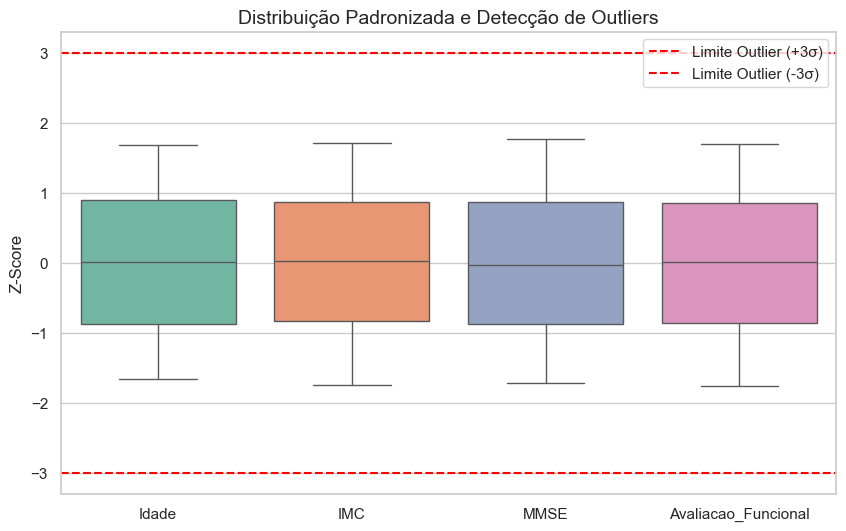

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_zscore[['Idade', 'IMC', 'MMSE', 'Avaliacao_Funcional']], palette="Set2")
plt.axhline(3, color='red', linestyle='--', label='Limite Outlier (+3σ)')
plt.axhline(-3, color='red', linestyle='--', label='Limite Outlier (-3σ)')
plt.title('Distribuição Padronizada e Detecção de Outliers', fontsize=14)
plt.ylabel('Z-Score')
plt.legend()
plt.show()

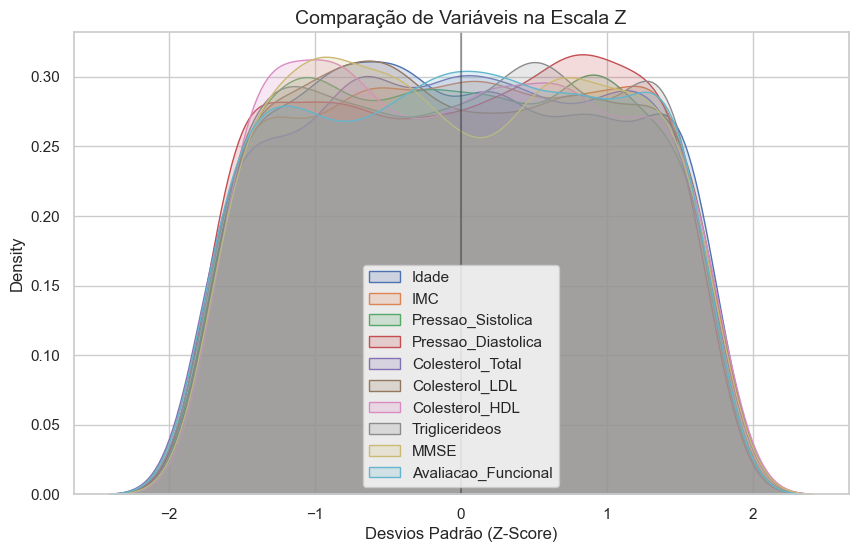

In [16]:
plt.figure(figsize=(10, 6))
for col in colMedidas:
    sns.kdeplot(df_zscore[col], label=col.replace('Z_', ''), fill=True, alpha=0.2)

plt.axvline(0, color='black', linestyle='-', alpha=0.3)
plt.title('Comparação de Variáveis na Escala Z', fontsize=14)
plt.xlabel('Desvios Padrão (Z-Score)')
plt.legend()
plt.show()

<h3>Medidas de Associação</h3>

In [17]:
matriz_cov = df_medidas[colMedidas].cov()

display(Markdown("### Matriz de Covariância"))
display(matriz_cov.round(4))

### Matriz de Covariância

,Idade,IMC,Pressao_Sistolica,Pressao_Diastolica,Colesterol_Total,Colesterol_LDL,Colesterol_HDL,Triglicerideos,MMSE,Avaliacao_Funcional
Idade,80.8241,-1.0172,-1.2421,-0.7057,0.1499,1.3988,1.4152,-2.8075,-0.3279,0.1432
IMC,-1.0172,52.0914,-3.6099,-0.3204,0.3323,7.4130,6.4472,-13.2499,-0.2161,-0.6368
Pressao_Sistolica,-1.2421,-3.6099,673.3689,1.1823,20.4637,-8.2097,1.7695,-92.1625,-0.7931,0.9879
Pressao_Diastolica,-0.7057,-0.3204,1.1823,309.4959,11.4129,-11.8576,3.3301,-14.2248,-4.3315,1.6023
Colesterol_Total,0.1499,0.3323,20.4637,11.4129,1809.8416,19.0684,9.9583,-8.5007,-4.9973,-0.6578
Colesterol_LDL,1.3988,7.4130,-8.2097,-11.8576,19.0684,1880.6606,-37.2769,-24.6884,9.4810,-2.0341
Colesterol_HDL,1.4152,6.4472,1.7695,3.3301,9.9583,-37.2769,535.4214,35.9521,-1.0400,-0.2309
Triglicerideos,-2.8075,-13.2499,-92.1625,-14.2248,-8.5007,-24.6884,35.9521,10401.2912,-6.6889,-2.7162
MMSE,-0.3279,-0.2161,-0.7931,-4.3315,-4.9973,9.4810,-1.0400,-6.6889,74.1864,0.6212
Avaliacao_Funcional,0.1432,-0.6368,0.9879,1.6023,-0.6578,-2.0341,-0.2309,-2.7162,0.6212,8.3680


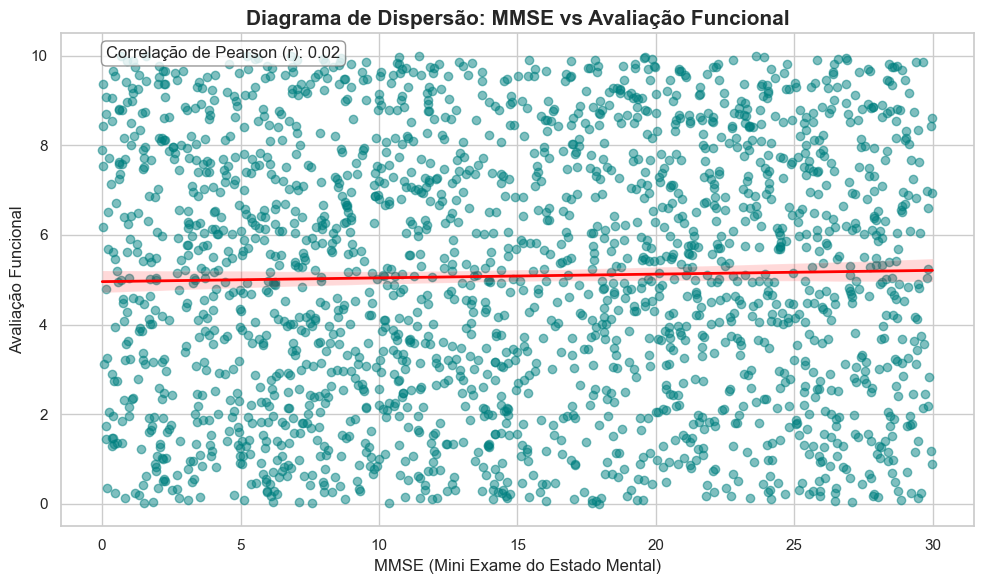

In [18]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.regplot(data=df_medidas, x='MMSE', y='Avaliacao_Funcional', 
            scatter_kws={'alpha':0.5, 'color':'teal'}, 
            line_kws={'color':'red', 'lw':2})

plt.title('Diagrama de Dispersão: MMSE vs Avaliação Funcional', fontsize=15, fontweight='bold')
plt.xlabel('MMSE (Mini Exame do Estado Mental)')
plt.ylabel('Avaliação Funcional')

r = df['MMSE'].corr(df['Avaliacao_Funcional'])
plt.annotate(f'Correlação de Pearson (r): {r:.2f}', 
             xy=(0.05, 0.95), xycoords='axes fraction', 
             fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
plt.tight_layout()
plt.show()